In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "http://books.toscrape.com/catalogue/page-{}.html"
all_books = []

print("⏳ جاري سحب البيانات من الموقع، انتظر ثواني...")

for page in range(1, 4):
    url = base_url.format(page)
    response = requests.get(url)

    if response.status_code == 200:
        soup = BeautifulSoup(response.content, 'html.parser')
        books = soup.find_all('article', class_='product_pod')

        for book in books:
            title = book.h3.a['title']
            price_text = book.find('p', class_='price_color').text
            price = float(price_text.replace('£', ''))
            rating_class = book.find('p', class_='star-rating')['class'][1]

            all_books.append({
                'Title': title,
                'Price (£)': price,
                'Rating': rating_class
            })
    else:
        print(f"خطأ في تحميل الصفحة {page}")

    time.sleep(1)

df = pd.DataFrame(all_books)
print("✅ تم سحب البيانات بنجاح! إليك عينة منها:")
print(df.head())

⏳ جاري سحب البيانات من الموقع، انتظر ثواني...
✅ تم سحب البيانات بنجاح! إليك عينة منها:
                                   Title  Price (£) Rating
0                   A Light in the Attic      51.77  Three
1                     Tipping the Velvet      53.74    One
2                             Soumission      50.10    One
3                          Sharp Objects      47.82   Four
4  Sapiens: A Brief History of Humankind      54.23   Five


📊 متوسط أسعار الكتب في السوق: £35.00
💰 أغلى كتاب سعره: £57.31
📉 أرخص كتاب سعره: £12.84
----------------------------------------


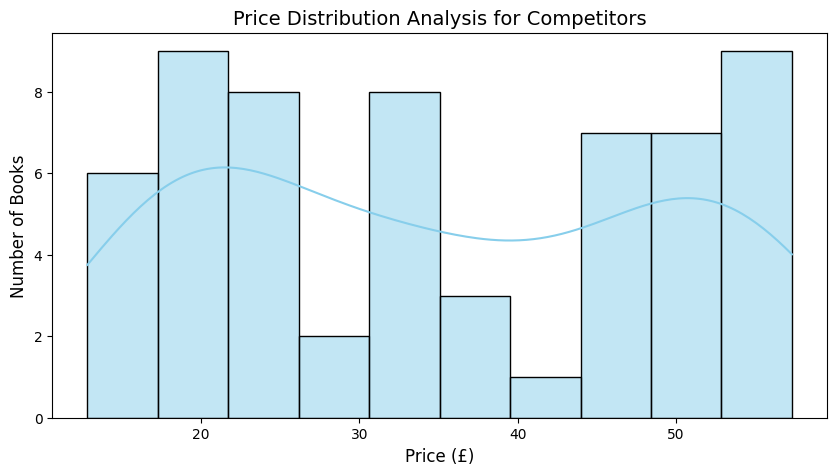

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. حساب بعض الإحصائيات السريعة للمنافسين (الموقع)
mean_price = df['Price (£)'].mean()
max_price = df['Price (£)'].max()
min_price = df['Price (£)'].min()

print(f"📊 متوسط أسعار الكتب في السوق: £{mean_price:.2f}")
print(f"💰 أغلى كتاب سعره: £{max_price:.2f}")
print(f"📉 أرخص كتاب سعره: £{min_price:.2f}")
print("-" * 40)

# 2. عمل رسم بياني يوضح توزيع الأسعار باستخدام Seaborn
plt.figure(figsize=(10, 5))
sns.histplot(df['Price (£)'], bins=10, kde=True, color='skyblue')

# إضافة عناوين للرسم البياني
plt.title('Price Distribution Analysis for Competitors', fontsize=14)
plt.xlabel('Price (£)', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)

# إظهار الرسم البياني
plt.show()